# INSTRON Mechanical Test Analysis
Loads raw data and results for each sensor, detects 5 cycles, computes strain/stress/Young's modulus.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
from scipy.stats import linregress
from pathlib import Path

DATA_DIR = Path(".")

SENSORS = [
    "50kohm_1",
    "50kohm_2",
    "50kohm_3",
    "150kohm",
    "200kohm",
    "210kohm",
    "250kohm",
    "460kohm",
]

DIMS = {
    "50kohm_1":  {"L0": 44.18, "W": 18.0, "T": 1.80},
    "50kohm_2":  {"L0": 32.97, "W": 18.0, "T": 1.80},
    "50kohm_3":  {"L0": 31.63,  "W": 18.0, "T": 1.80},
    "150kohm":   {"L0": 25.53, "W": 18.0, "T": 1.80},
    "200kohm":   {"L0": 40.42, "W": 18.0, "T": 1.80},
    "210kohm":   {"L0": 35.90, "W": 18.0, "T": 1.80},
    "250kohm":   {"L0": 26.50, "W": 18.0, "T": 1.80},
    "460kohm":   {"L0": 36.70, "W": 18.0, "T": 1.80},
}

In [5]:
def load_raw(sensor):
    path = DATA_DIR / f"{sensor}_RawData_1.csv"
    df = pd.read_csv(
        path, skiprows=2, header=None,
        names=["Time", "Extension", "Load"],
        decimal=",", encoding="utf-8",
    )
    return df.apply(pd.to_numeric, errors="coerce").dropna().reset_index(drop=True)

def load_dims(sensor):
    path = DATA_DIR / f"{sensor}_Results.csv"
    try:
        df = pd.read_csv(path, skiprows=2, header=None, decimal=",", encoding="utf-8")
        L0 = float(df.iloc[0, 1])
    except Exception:
        L0 = DIMS[sensor]["L0"]
    return L0, DIMS[sensor]["W"], DIMS[sensor]["T"]

def detect_cycles(ext, n_cycles=5):
    min_dist = max(10, len(ext) // (n_cycles * 3))
    peaks, _ = find_peaks(ext.values, distance=min_dist, prominence=ext.max() * 0.3)
    if len(peaks) < n_cycles:
        step = len(ext) // n_cycles
        peaks = [step * i + step // 2 for i in range(n_cycles)]
    peaks = peaks[:n_cycles]
    cycles = []
    for i, pk in enumerate(peaks):
        start = 0 if i == 0 else peaks[i-1] + (pk - peaks[i-1]) // 2
        end   = len(ext) - 1 if i == n_cycles - 1 else pk + (peaks[i+1] - pk) // 2
        cycles.append((start, pk, end))
    return cycles

raw = {s: load_raw(s) for s in SENSORS if (DATA_DIR / f"{s}_RawData_1.csv").exists()}
SENSORS = list(raw.keys())
print("Loaded sensors:", SENSORS)

Loaded sensors: ['50kohm_1', '50kohm_2', '50kohm_3', '150kohm', '200kohm', '210kohm', '250kohm', '460kohm']


## 1 — Global summary table

In [6]:
rows = []
for s in SENSORS:
    df = raw[s]
    L0, W, T = load_dims(s)
    ext    = df["Extension"]
    load   = df["Load"]
    strain = ext / L0
    cycles = detect_cycles(ext)
    c1 = slice(cycles[0][0], cycles[0][2])
    c5 = slice(cycles[4][0], cycles[4][2])
    idx_50 = (ext - 0.5 * ext.max()).abs().idxmin()
    rows.append({
        "Sensor": s,
        "Initial length L0 (mm)": round(L0, 2),
        "Max strain e (-)": round(strain.max(), 4),
        "Extension at 50% max ext (mm)": round(ext.iloc[idx_50], 3),
        "Max force cycle 1 (N)": round(load.iloc[c1].max(), 4),
        "Max force cycle 5 (N)": round(load.iloc[c5].max(), 4),
    })

summary_df = pd.DataFrame(rows).set_index("Sensor")
display(summary_df)

,Initial length L0 (mm),Max strain e (-),Extension at 50% max ext (mm),Max force cycle 1 (N),Max force cycle 5 (N)
Sensor,,,,,
50kohm_1,44.18,0.5001,11.048,1.7045,1.4222
50kohm_2,32.97,0.5001,8.262,2.6480,2.3275
50kohm_3,31.63,0.5001,7.929,2.7068,2.4302
150kohm,25.53,0.5001,6.382,3.5323,2.9126
200kohm,40.42,0.5001,10.114,2.8293,2.3893
210kohm,35.90,0.5001,8.964,3.6413,3.1238
250kohm,26.50,0.5001,6.631,1.9900,1.6436
460kohm,36.70,0.5001,9.179,4.2449,3.5306


## 2 — Per-sensor plots: Strain vs Time  |  Force vs Time  |  Force vs Strain

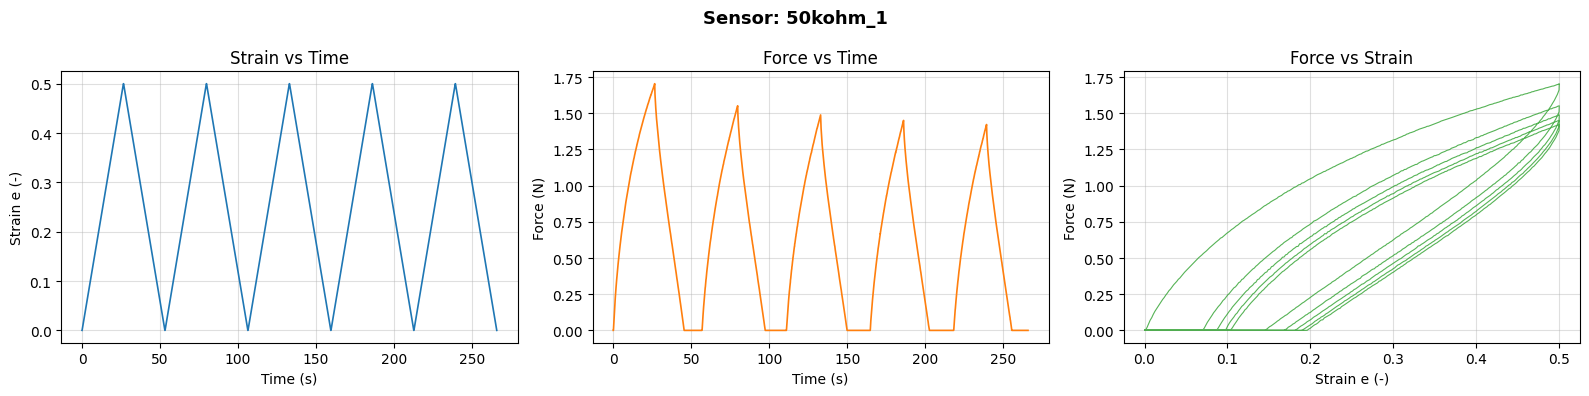

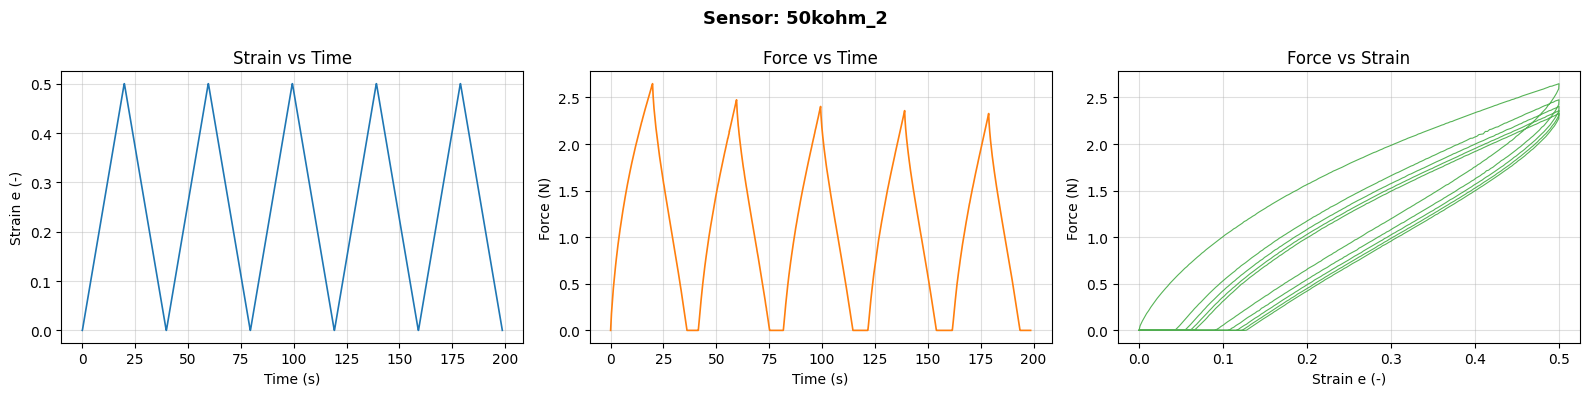

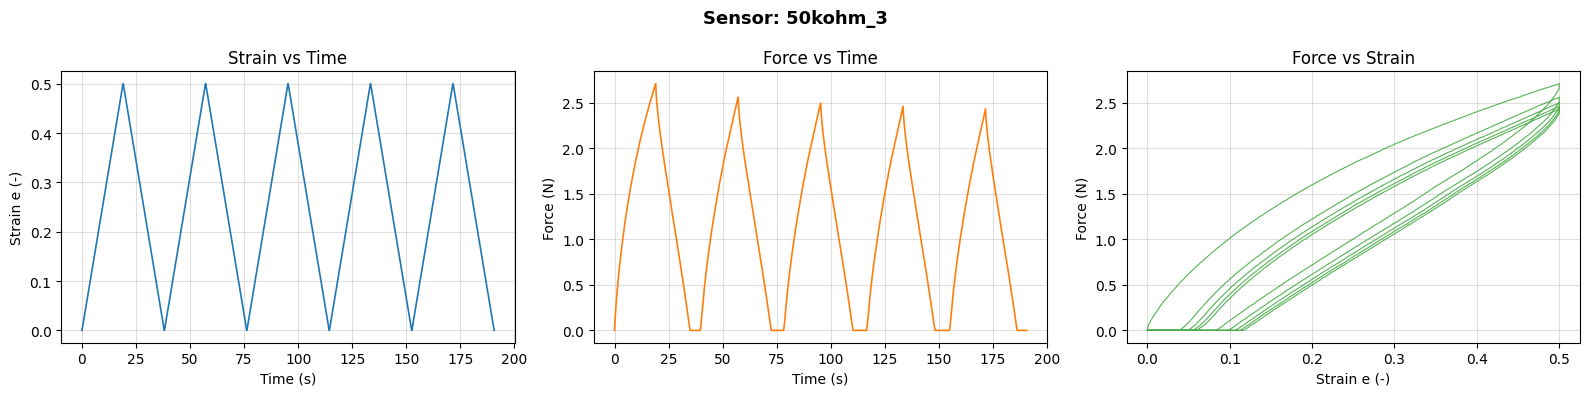

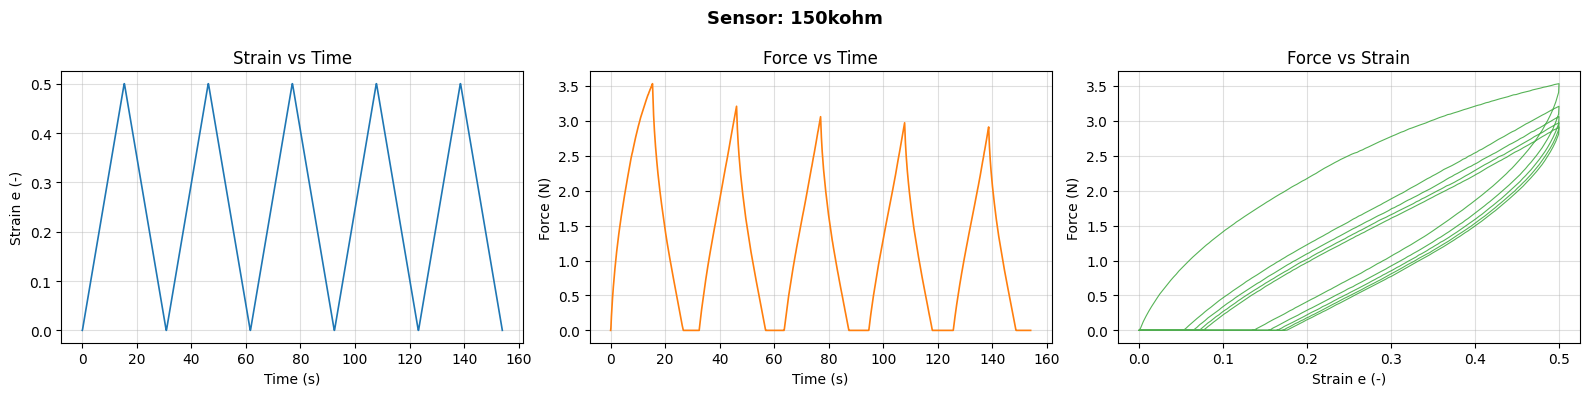

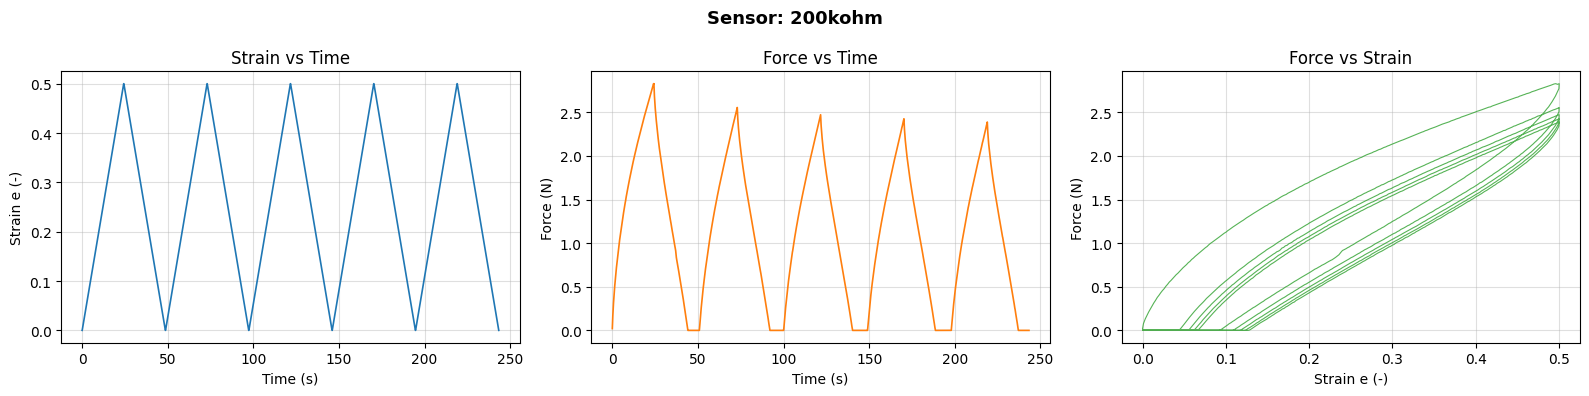

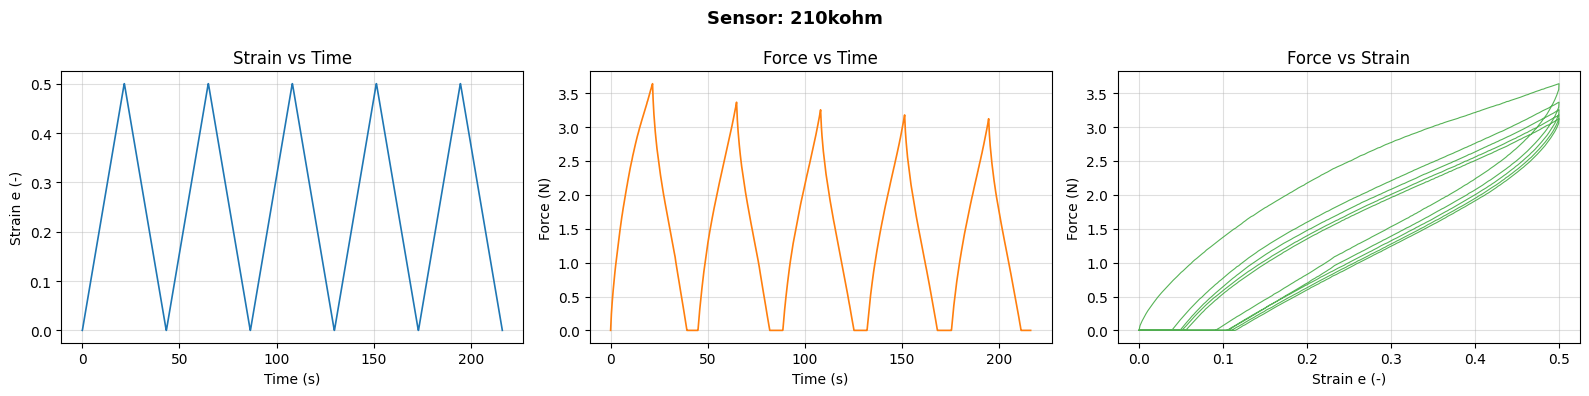

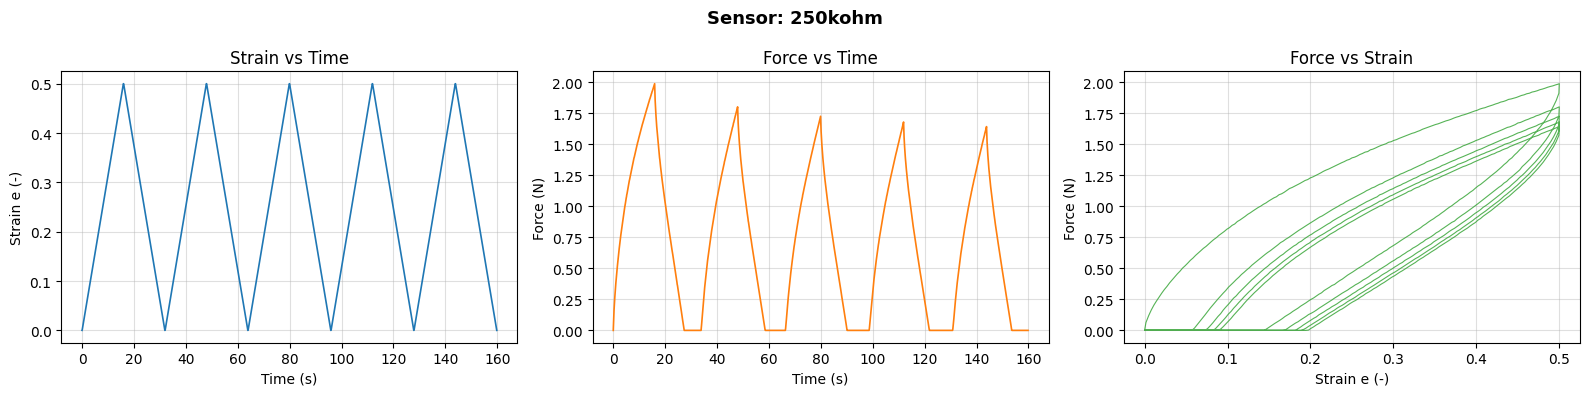

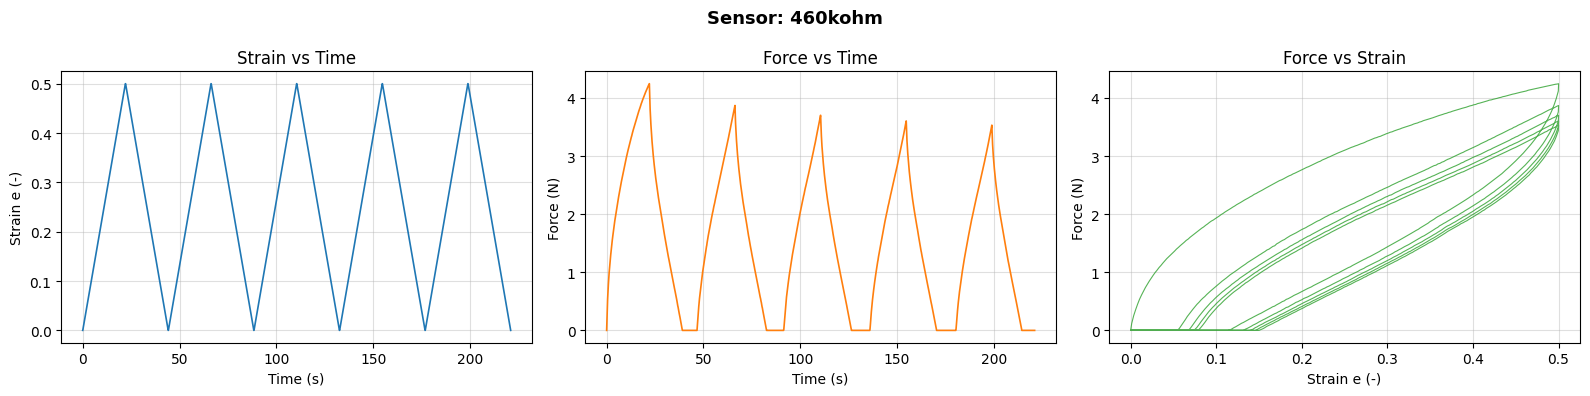

In [7]:
for s in SENSORS:
    df = raw[s]
    L0, W, T = load_dims(s)
    t      = df["Time"]
    ext    = df["Extension"]
    load   = df["Load"].clip(lower=0)
    strain = ext / L0

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    fig.suptitle(f"Sensor: {s}", fontsize=13, fontweight="bold")

    axes[0].plot(t, strain, lw=1.2, color="C0")
    axes[0].set_xlabel("Time (s)"); axes[0].set_ylabel("Strain e (-)"); axes[0].set_title("Strain vs Time"); axes[0].grid(True, alpha=0.4)

    axes[1].plot(t, load, lw=1.2, color="C1")
    axes[1].set_xlabel("Time (s)"); axes[1].set_ylabel("Force (N)"); axes[1].set_title("Force vs Time"); axes[1].grid(True, alpha=0.4)

    axes[2].plot(strain, load, lw=0.8, alpha=0.8, color="C2")
    axes[2].set_xlabel("Strain e (-)"); axes[2].set_ylabel("Force (N)"); axes[2].set_title("Force vs Strain"); axes[2].grid(True, alpha=0.4)

    fig.tight_layout()
    fig.savefig(DATA_DIR / f"{s}_plots.png", dpi=150, bbox_inches="tight")
    plt.show()

## 3 — Per-sensor cycle tables (5 cycles)

In [8]:
for s in SENSORS:
    df = raw[s]
    L0, W, T = load_dims(s)
    A      = W * T
    ext    = df["Extension"]
    load   = df["Load"]
    strain = ext / L0
    stress = load / A
    cycles = detect_cycles(ext)

    cycle_rows = []
    for n, (start, peak, end) in enumerate(cycles, 1):
        sl = slice(start, end + 1)
        t_sl = df["Time"].iloc[sl]
        cycle_rows.append({
            "Cycle": n,
            "Duration (s)": round(t_sl.iloc[-1] - t_sl.iloc[0], 2),
            "Max strain e (-)": round(strain.iloc[sl].max(), 4),
            "Max force (N)": round(load.iloc[sl].max(), 4),
            "Max stress s (MPa)": round(stress.iloc[sl].max(), 6),
        })

    print(f"\nSensor: {s}  |  L0={L0} mm  A={A} mm2")
    display(pd.DataFrame(cycle_rows).set_index("Cycle"))


Sensor: 50kohm_1  |  L0=44.18 mm  A=32.4 mm2


,Duration (s),Max strain e (-),Max force (N),Max stress s (MPa)
Cycle,,,,
1,53.15,0.5000,1.7045,0.052608
2,53.19,0.5000,1.5519,0.047898
3,53.19,0.5000,1.4885,0.045942
4,53.19,0.5001,1.4506,0.044772
5,53.19,0.5001,1.4222,0.043897



Sensor: 50kohm_2  |  L0=32.97 mm  A=32.4 mm2


,Duration (s),Max strain e (-),Max force (N),Max stress s (MPa)
Cycle,,,,
1,39.70,0.5001,2.6480,0.081729
2,39.74,0.5001,2.4748,0.076382
3,39.74,0.5001,2.4033,0.074175
4,39.74,0.5001,2.3586,0.072796
5,39.74,0.5001,2.3275,0.071836



Sensor: 50kohm_3  |  L0=31.63 mm  A=32.4 mm2


...

,Duration (s),Max strain e (-),Max force (N),Max stress s (MPa)
Cycle,,,,
1,43.21,0.5001,3.6413,0.112387
2,43.26,0.5001,3.3675,0.103936
3,43.26,0.5001,3.2553,0.100471
4,43.26,0.5001,3.1802,0.098154
5,43.25,0.5001,3.1238,0.096414



Sensor: 250kohm  |  L0=26.5 mm  A=32.4 mm2


,Duration (s),Max strain e (-),Max force (N),Max stress s (MPa)
Cycle,,,,
1,31.93,0.5001,1.9900,0.061419
2,31.98,0.5001,1.8030,0.055647
3,31.97,0.5001,1.7271,0.053305
4,31.97,0.5001,1.6808,0.051876
5,31.97,0.5001,1.6436,0.050729



Sensor: 460kohm  |  L0=36.7 mm  A=32.4 mm2


,Duration (s),Max strain e (-),Max force (N),Max stress s (MPa)
Cycle,,,,
1,44.17,0.5001,4.2449,0.131016
2,44.21,0.5001,3.8698,0.119438
3,44.21,0.5001,3.7011,0.114231
4,44.21,0.5001,3.6037,0.111225
5,44.21,0.5001,3.5306,0.108968


## 4 — Young's modulus: Stress-Strain with linear regression

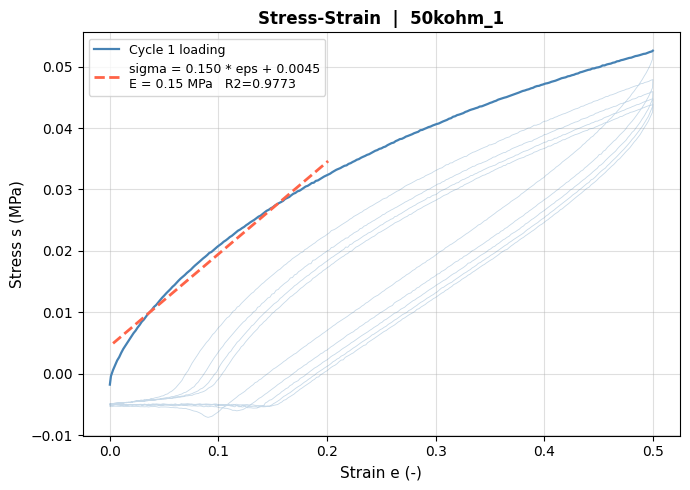

E = 0.15 MPa  (R2=0.9773)


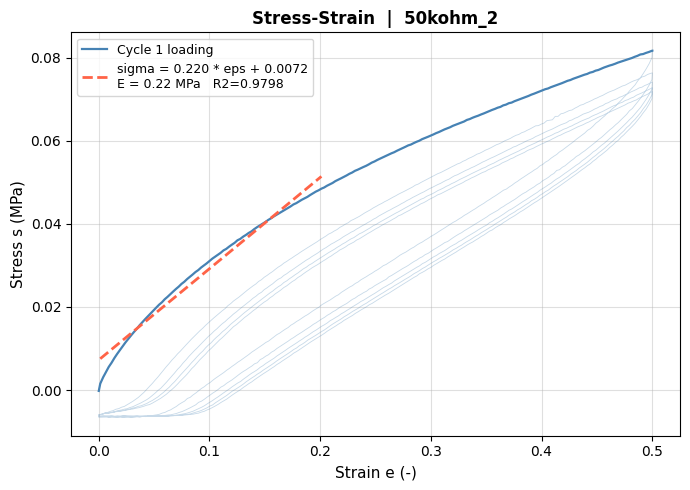

E = 0.22 MPa  (R2=0.9798)


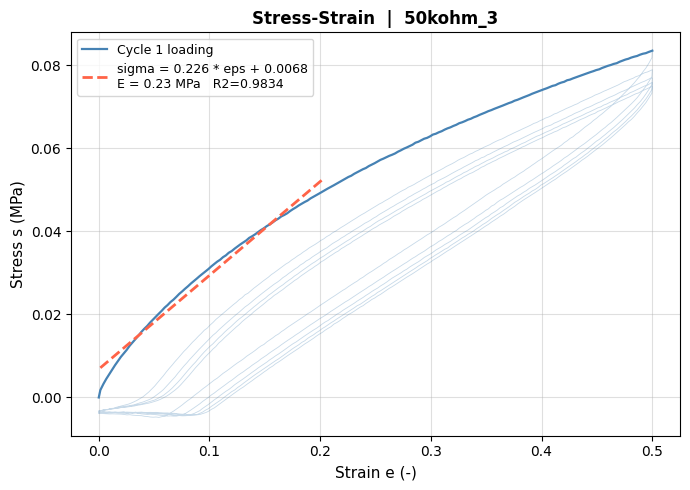

E = 0.23 MPa  (R2=0.9834)


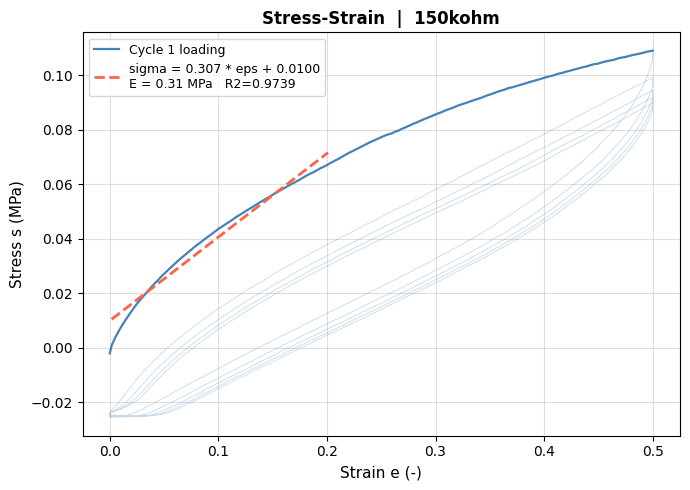

E = 0.31 MPa  (R2=0.9739)


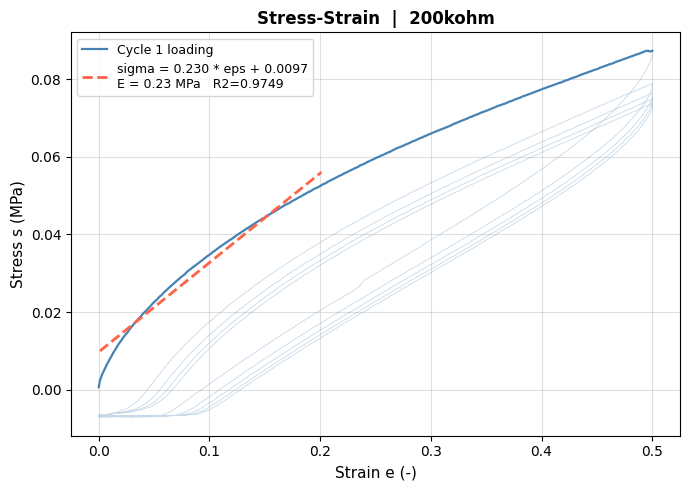

E = 0.23 MPa  (R2=0.9749)


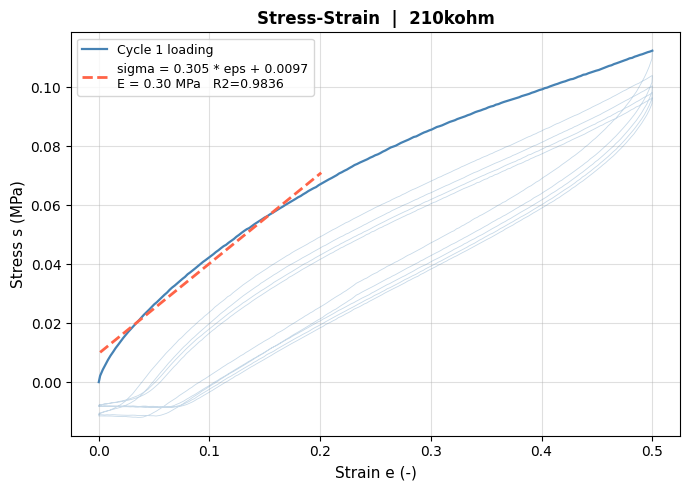

E = 0.30 MPa  (R2=0.9836)


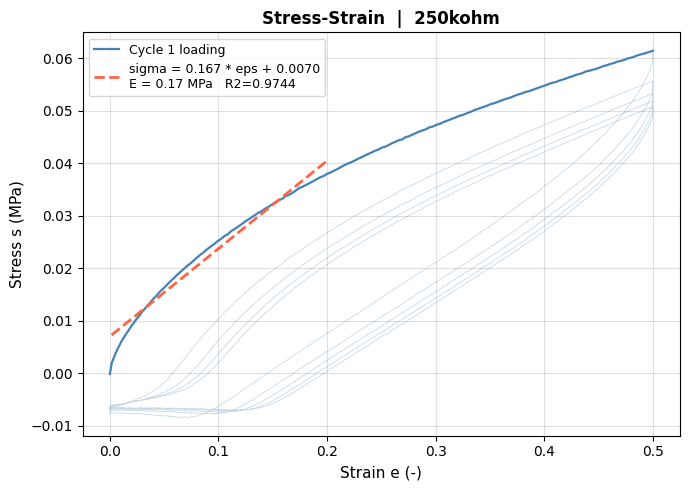

E = 0.17 MPa  (R2=0.9744)


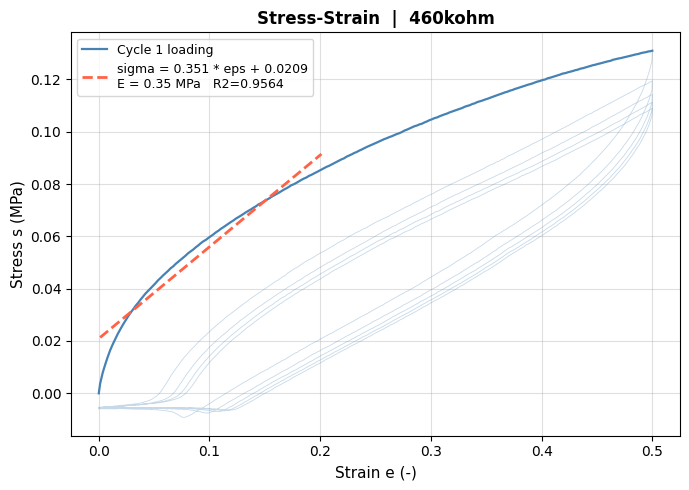

E = 0.35 MPa  (R2=0.9564)

Young modulus summary


,E (MPa),R2
Sensor,,
50kohm_1,0.15,0.9773
50kohm_2,0.22,0.9798
50kohm_3,0.23,0.9834
150kohm,0.31,0.9739
200kohm,0.23,0.9749
210kohm,0.30,0.9836
250kohm,0.17,0.9744
460kohm,0.35,0.9564


In [9]:
young_rows = []

for s in SENSORS:
    df = raw[s]
    L0, W, T = load_dims(s)
    A      = W * T
    ext    = df["Extension"]
    load   = df["Load"]
    strain = (ext / L0).values
    stress = (load / A).values

    cycles = detect_cycles(ext)
    start, peak, _ = cycles[0]

    # First loading ramp — the most linear region
    eps_ramp = strain[start:peak + 1]
    sig_ramp = stress[start:peak + 1]
    mask = (eps_ramp > 0) & (sig_ramp > 0)
    eps_lin = eps_ramp[mask]
    sig_lin = sig_ramp[mask]

    # Linear regression on first 40% of loading ramp
    n_lin = max(5, int(0.4 * len(eps_lin)))
    slope, intercept, r, *_ = linregress(eps_lin[:n_lin], sig_lin[:n_lin])
    E_MPa = slope
    young_rows.append({"Sensor": s, "E (MPa)": round(E_MPa, 2), "R2": round(r**2, 4)})

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.plot(strain, stress, lw=0.6, alpha=0.3, color="steelblue")
    ax.plot(eps_ramp, sig_ramp, lw=1.6, color="steelblue", label="Cycle 1 loading")

    eps_fit = np.linspace(eps_lin[:n_lin].min(), eps_lin[:n_lin].max(), 200)
    sig_fit = slope * eps_fit + intercept
    ax.plot(
        eps_fit, sig_fit, "--", color="tomato", lw=2.0,
        label=f"sigma = {slope:.3f} * eps + {intercept:.4f}\nE = {E_MPa:.2f} MPa   R2={r**2:.4f}"
    )

    ax.set_xlabel("Strain e (-)", fontsize=11)
    ax.set_ylabel("Stress s (MPa)", fontsize=11)
    ax.set_title(f"Stress-Strain  |  {s}", fontsize=12, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.4)
    fig.tight_layout()
    fig.savefig(DATA_DIR / f"{s}_stress_strain.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"E = {E_MPa:.2f} MPa  (R2={r**2:.4f})")

print("\nYoung modulus summary")
display(pd.DataFrame(young_rows).set_index("Sensor"))